In [82]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/dummy-advertising-and-sales-data/Dummy Data HSS.csv


In [83]:
import matplotlib.pyplot as plt

In [84]:
data = pd.read_csv('/kaggle/input/dummy-advertising-and-sales-data/Dummy Data HSS.csv')
data.columns=['TV','Radio','Social Media','Influencer','Sales']

In [85]:
data=data.dropna().reset_index(drop=True)

In [86]:
data.head()

,TV,Radio,Social Media,Influencer,Sales
0,16.0,6.566231,2.907983,Mega,54.732757
1,13.0,9.237765,2.409567,Mega,46.677897
2,41.0,15.886446,2.913410,Mega,150.177829
3,83.0,30.020028,6.922304,Mega,298.246340
4,15.0,8.437408,1.405998,Micro,56.594181


In [87]:
data['Influencer'].value_counts()

Influencer
Mega     1152
Micro    1148
Nano     1134
Macro    1112
Name: count, dtype: int64

In [88]:
print("Missing values in each column:\n",data.isnull().sum())

Missing values in each column:
 TV              0
Radio           0
Social Media    0
Influencer      0
Sales           0
dtype: int64


In [89]:
data['Influencer']=data['Influencer'].map({'Mega':1,'Macro':0.6,'Micro':0.4, 'Nano':0.1})

In [90]:
data.head()

,TV,Radio,Social Media,Influencer,Sales
0,16.0,6.566231,2.907983,1.0,54.732757
1,13.0,9.237765,2.409567,1.0,46.677897
2,41.0,15.886446,2.913410,1.0,150.177829
3,83.0,30.020028,6.922304,1.0,298.246340
4,15.0,8.437408,1.405998,0.4,56.594181


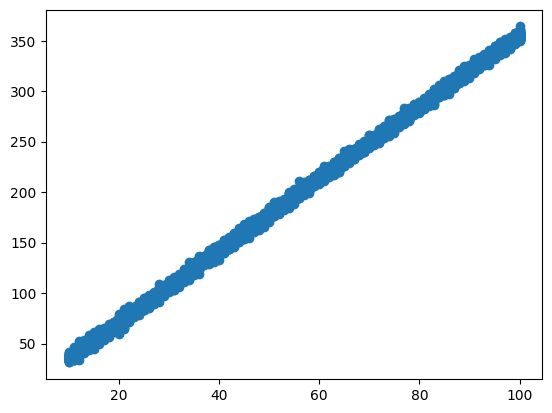

In [91]:
x=data["TV"]
y=data["Sales"]
plt.scatter(x,y)
plt.show()

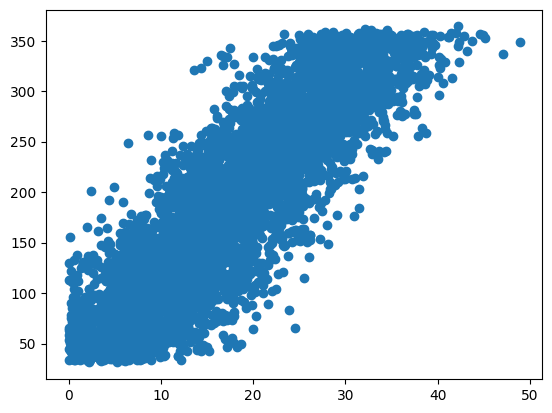

In [92]:
x=data["Radio"]
y=data["Sales"]
plt.scatter(x,y)
plt.show()

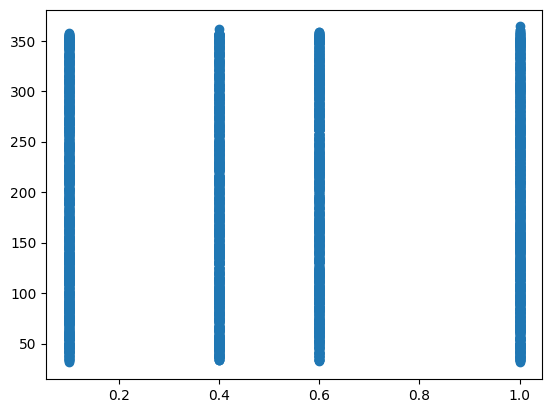

In [93]:
x=data["Influencer"]
y=data["Sales"]
plt.scatter(x,y)
plt.show()

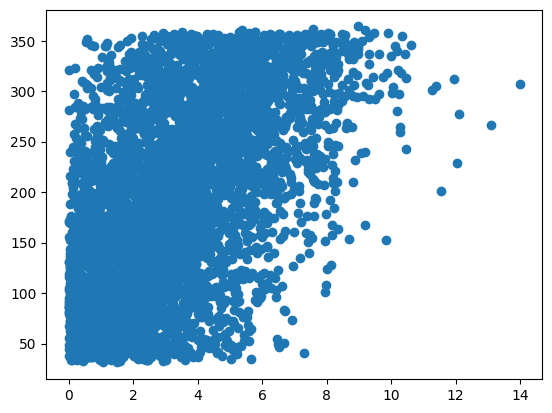

In [94]:
x=data["Social Media"]
y=data["Sales"]
plt.scatter(x,y)
plt.show()

In [95]:
X=data[['TV','Radio','Social Media','Influencer']]
Y=data[['Sales']]

In [96]:
x_train=data.iloc[:3636,:4]
y_train=data.iloc[:3636,4]
x_test=data.iloc[3636:,:4]
y_test=data.iloc[3636:,4]

In [97]:
x_train=x_train.values
x_test=x_test.values
y_train=y_train.values.reshape(-1,1)
y_test=y_test.values.reshape(-1,1)

In [98]:
mean=x_train.mean()
std=x_train.std()
x_train=(x_train-mean)//std
x_test=(x_test-mean)//std

In [99]:
class LinearRegression:
  def fit(self,x_train,y_train,lr=0.001,epochs=2000):
    n_samples,n_features=x_train.shape
    self.bias=0
    self.weights=np.zeros((n_features,1))
    batch_size=32
    for epoch in range(epochs):
        p=np.random.permutation(n_samples)
        x_train_shuffled=x_train[p]
        y_train_shuffled=y_train[p]
        for i in range(0,n_samples,batch_size):
            x_batch=x_train_shuffled[i:i+batch_size]
            y_batch=y_train_shuffled[i:i+batch_size]
            y_pred=np.dot(x_batch,self.weights)+self.bias
            dw=(1/batch_size)*np.dot(x_batch.T,y_pred-y_batch)
            dz=(1/batch_size)*np.sum(y_pred-y_batch)
            self.weights-=lr*dw
            self.bias-=lr*dz
        if(epoch%100==0):
            mse=np.mean((y_pred-y_batch)**2)
            print(f"Epoch {epoch} MSE {mse}")
  def predict(self,x):
      x.reshape(1,-1)
      y_pred=np.dot(x,self.weights)+self.bias
      return y_pred
def r2_score(y_true,y_pred):
    y_true=y_true.reshape(-1,1)
    y_pred=y_pred.reshape(-1,1)
    ss_res=np.sum((y_true-y_pred)**2)          
    ss_tot=np.sum((y_true-np.mean(y_true))**2) 
    r2=1-(ss_res/ss_tot)
    return r2

model = LinearRegression()
model.fit(x_train,y_train)
y_pred=np.dot(x_test,model.weights)+model.bias
print("R2 Score:", r2_score(y_test,y_pred))
arr=np.array([66,77,5,0.4])
print(model.predict(arr))

       
            

Epoch 0 MSE 12587.278015690245
Epoch 100 MSE 463.1267515205037
Epoch 200 MSE 665.1328846910676
Epoch 300 MSE 344.9542830664585
Epoch 400 MSE 750.5564061543157
Epoch 500 MSE 597.9404124949109
Epoch 600 MSE 568.7469847632158
Epoch 700 MSE 692.7907399075275
Epoch 800 MSE 489.8004872592699
Epoch 900 MSE 453.5765012960941
Epoch 1000 MSE 842.855952646067
Epoch 1100 MSE 564.4605149291239
Epoch 1200 MSE 737.5698702702184
Epoch 1300 MSE 458.05443963267516
Epoch 1400 MSE 634.4095338765852
Epoch 1500 MSE 608.5826862514905
Epoch 1600 MSE 582.4074833548868
Epoch 1700 MSE 527.940809326894
Epoch 1800 MSE 594.5086361482334
Epoch 1900 MSE 499.22507598472623
R2 Score: 0.9324205022127393
[6655.38013412]
